## Galaxy vs quasars

We're now going to classify galaxy vs quasars in the Sloan Digital Sky Survey. 

This is one of the most famous example of machine-learning classification in astronomy. For some recent work see e.g. 
- *Identifying galaxies, quasars, and stars with machine learning: A new catalogue of classifications for 111 million SDSS sources without spectra* Clarke et al (2019) [arXiv:1909.10963](https://arxiv.org/abs/1909.10963)
- *Quasar and galaxy classification in Gaia Data Release 2* Bailer-Jones et al (2019) [arXiv:1910.05255](https://arxiv.org/abs/1910.05255)

#### Data

The dataset is at `solutions/galaxyquasar.csv`. I have extracted it myself from the SDSS database using the SQL query reported [here](https://www.astroml.org/_modules/astroML/datasets/sdss_galaxy_colors.html#fetch_sdss_galaxy_colors)

(If you've never used [SQL](https://en.wikipedia.org/wiki/SQL) and want to learn something new it's computing, it's very powerful)

#### Tasks

- Create arrays for the $(u-g)$, $(g-r)$, $(r-i)$, and $(i-z)$ colors. Also create an array with the class labels where galaxy=$0$ and quasar=$1$. 
- Classify the dataset against the target label.
- Try some of the classification methods we've seen so far and evaluate the performance using the ROC curve.
- Remember to split the dataset into training and validation...

#### Ideas
- Try using different colors (a subset of them first, than all together). Which is the most important feature?
- What are the colors that better satisfy or invalidate the "Naive" assumption of independence between the attributes?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data = pd.read_csv("galaxyquasar.csv")
data

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [3]:
labels = ['u', 'g','r','i', 'z' ]
filters = []
for i in range(len(labels)-1):
    filters.append(data[labels[i]]-data[labels[i+1]])
filters = np.array(filters)
filters[0,:]

array([0.43537, 1.76946, 1.73268, ..., 1.31842, 1.27429, 1.05021])

In [4]:
classes = np.zeros(len(data['class']))
for i in range(len(data['class'])):
    if data['class'][i] == 'QSO':
        classes[i] = 1.0
classes

array([1., 0., 0., ..., 0., 0., 0.])

In [5]:
from sklearn.model_selection import train_test_split
ug_train, ug_test, gr_train, gr_test, ri_train, ri_test, iz_train, iz_test, class_train, class_test = train_test_split(
                    filters[0,:], filters[1,:], 
                    filters[2,:], filters[3,:], classes,
                    train_size=0.70, test_size=0.30)

In [6]:
#Let's start by using a sub-set of colors far away from each others like (u-g) and (i-z)!
X = np.column_stack([ug_train, iz_train])
X_test = np.column_stack([ug_test, iz_test])
y = class_train

In [7]:
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from  astroML.classification import GMMBayes
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve as ROC
from sklearn.metrics import precision_recall_curve as PRC

GNB = GaussianNB()
QDA = QuadraticDiscriminantAnalysis(reg_param=0.1)
GMMB = GMMBayes(n_components=3)
KNN = KNeighborsClassifier(n_neighbors=5)
models = [GNB, QDA, GMMB, KNN]
names = ['GNB', 'QDA', 'GMMB', 'KNN']
fpr = []
tpr = []
pre = []
rec = []

for model in models: 
    model.fit(X, y)
    y_pred = model.predict_proba(X_test)
    fpr_mdl, tpr_mdl, th_mdl = ROC(class_test, y_pred[:, 1])
    pr_mdl, acc_mdl, th_mdl = PRC(class_test, y_pred[:, 1])
    fpr.append(fpr_mdl)
    tpr.append(tpr_mdl)
    pre.append(pr_mdl)
    rec.append(acc_mdl)

fpr = np.array(fpr, dtype=object)
tpr = np.array(tpr, dtype=object)
pre = np.array(pre, dtype=object)
rec = np.array(rec, dtype=object)

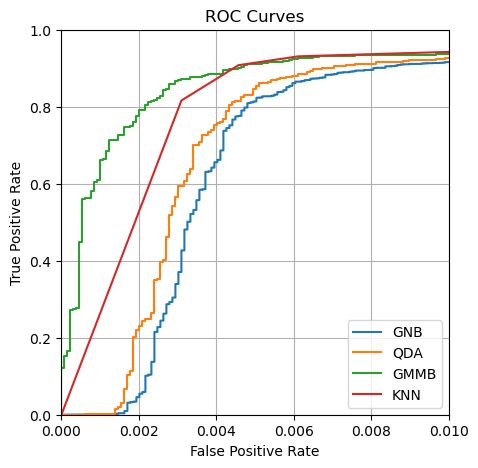

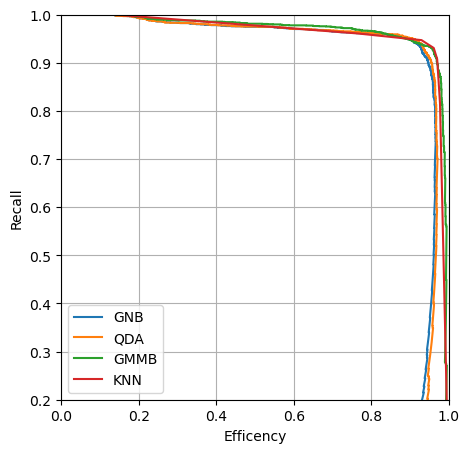

In [8]:
plt.figure(figsize=(5, 5))
for i in range(len(models)):
    plt.plot(fpr[i], tpr[i], label=names[i])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.xlim(0,0.01)
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 5))
for i in range(len(models)):
    plt.plot(pre[i], rec[i], label=names[i])
plt.xlabel('Efficency')
plt.ylabel('Recall')
plt.xlim(0,1)
plt.ylim(0.2,1)
plt.legend()
plt.grid(True)
plt.show()

In [9]:
#And let's now see how the Naive Bayes classifier changes with filters that are close to eachother 
X = np.column_stack([ug_train, gr_train])
X_test = np.column_stack([ug_test, gr_test])
y = class_train

fpr_cls = []
tpr_cls = []
pre_cls = []
rec_cls = []

for model in models: 
    model.fit(X, y)
    y_pred = model.predict_proba(X_test)
    fpr_mdl, tpr_mdl, th_mdl = ROC(class_test, y_pred[:, 1])
    pr_mdl, acc_mdl, th_mdl = PRC(class_test, y_pred[:, 1])
    fpr_cls.append(fpr_mdl)
    tpr_cls.append(tpr_mdl)
    pre_cls.append(pr_mdl)
    rec_cls.append(acc_mdl)

fpr_cls = np.array(fpr_cls, dtype=object)
tpr_cls = np.array(tpr_cls, dtype=object)
pre_cls = np.array(pre_cls, dtype=object)
rec_cls = np.array(rec_cls, dtype=object)

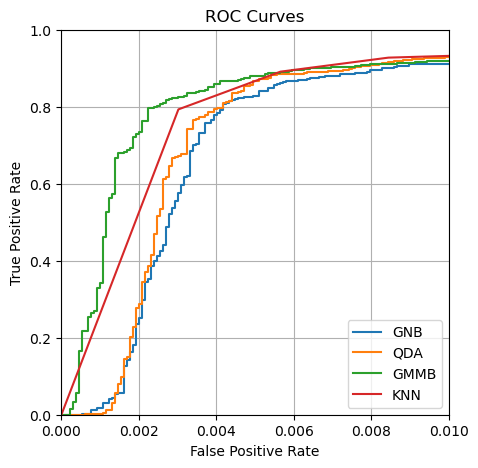

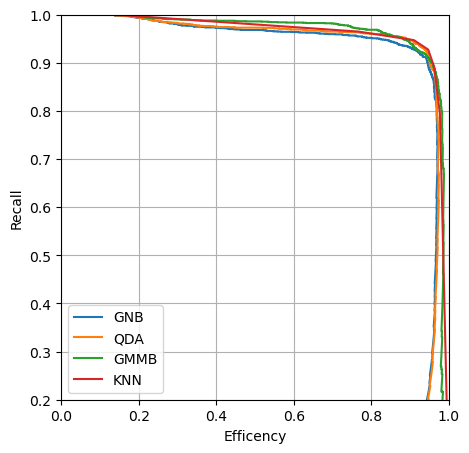

In [10]:
plt.figure(figsize=(5, 5))
for i in range(len(models)):
    plt.plot(fpr_cls[i], tpr_cls[i], label=names[i])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.xlim(0,0.01)
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 5))
for i in range(len(models)):
    plt.plot(pre_cls[i], rec_cls[i], label=names[i])
plt.xlabel('Efficency')
plt.ylabel('Recall')
plt.xlim(0,1)
plt.ylim(0.2,1)
plt.legend()
plt.grid(True)
plt.show()

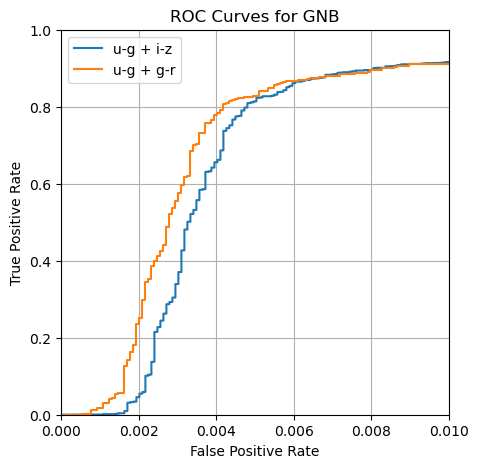

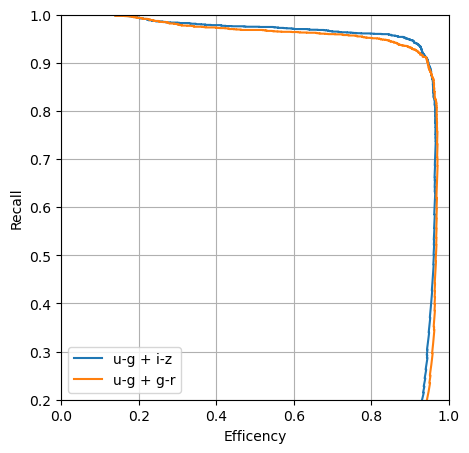

In [11]:
plt.figure(figsize=(5, 5))
plt.plot(fpr[0], tpr[0], label='u-g + i-z')
plt.plot(fpr_cls[0], tpr_cls[0], label='u-g + g-r')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for GNB')
plt.xlim(0,0.01)
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 5))
plt.plot(pre[0], rec[0], label='u-g + i-z')
plt.plot(pre_cls[0], rec_cls[0], label='u-g + g-r')
plt.xlabel('Efficency')
plt.ylabel('Recall')
plt.xlim(0,1)
plt.ylim(0.2,1)
plt.legend()
plt.grid(True)
plt.show()

At first we were expecting the GNB classifier to perform worse on the correlated data, nevertheless this does not happend! Furthermore every classifier seem to perform better. So let's take a look at the data we are using! 

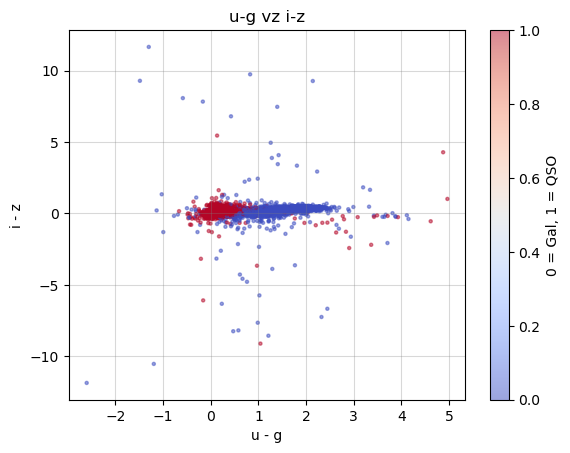

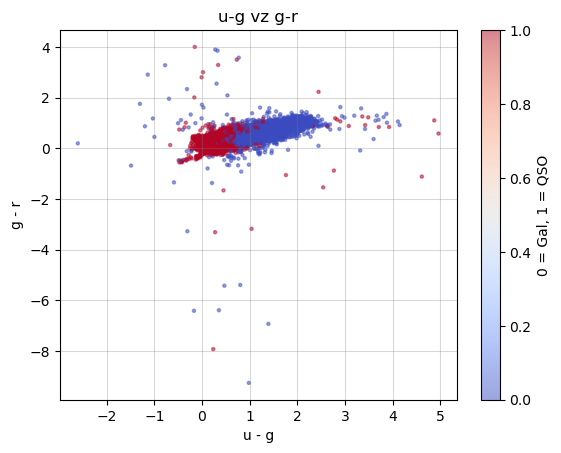

In [12]:
plt.scatter(ug_train, iz_train, c = class_train, cmap='coolwarm', s = 5, alpha = 0.5)
plt.xlabel('u - g')
plt.ylabel('i - z')
plt.colorbar(label='0 = Gal, 1 = QSO')
plt.grid(c='gray', alpha = 0.3)
plt.title('u-g vz i-z')
plt.show()

plt.scatter(ug_train, gr_train, c = class_train, cmap = 'coolwarm', s = 5, alpha = 0.5)
plt.xlabel('u - g')
plt.ylabel('g - r')
plt.colorbar(label='0 = Gal, 1 = QSO')
plt.grid(c='gray', alpha = 0.3)
plt.title('u-g vz g-r')
plt.show()

That's why! Using the two 'far away' filters the classification is harder in general, quasars and galaxies overlap way more than when using two close by filters ! So, even if the GNB classifier does not consider the correlation between the 2 filters, it is still easier to distinguish between the two classes! 

So what happens when we use all of the data ? 

In [13]:
X = np.column_stack([ug_train, gr_train, ri_train, iz_train])
X_test = np.column_stack([ug_test, gr_test, ri_test, iz_test])
y = class_train

In [14]:
fpr_tot = []
tpr_tot = []
pre_tot = []
rec_tot = []

for model in models: 
    model.fit(X, y)
    y_pred = model.predict_proba(X_test)
    fpr_mdl, tpr_mdl, th_mdl = ROC(class_test, y_pred[:, 1])
    pr_mdl, acc_mdl, th_mdl = PRC(class_test, y_pred[:, 1])
    fpr_tot.append(fpr_mdl)
    tpr_tot.append(tpr_mdl)
    pre_tot.append(pr_mdl)
    rec_tot.append(acc_mdl)

fpr_tot = np.array(fpr_tot, dtype=object)
tpr_tot = np.array(tpr_tot, dtype=object)
pre_tot = np.array(pre_tot, dtype=object)
rec_tot = np.array(rec_tot, dtype=object)

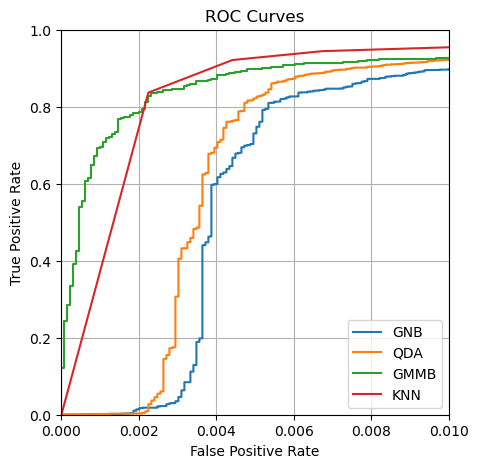

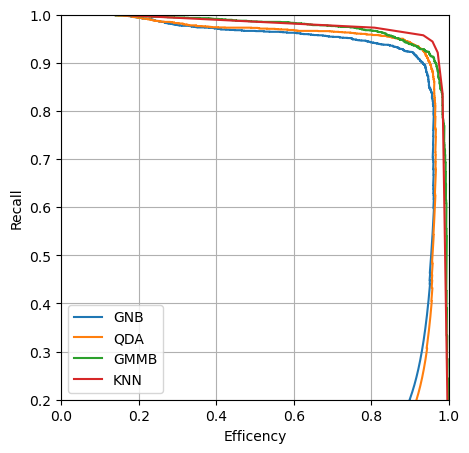

In [15]:
plt.figure(figsize=(5, 5))
for i in range(len(models)):
    plt.plot(fpr_tot[i], tpr_tot[i], label=names[i])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.xlim(0,0.01)
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 5))
for i in range(len(models)):
    plt.plot(pre_tot[i], rec_tot[i], label=names[i])
plt.xlabel('Efficency')
plt.ylabel('Recall')
plt.xlim(0,1)
plt.ylim(0.2,1.)
plt.legend()
plt.grid(True)
plt.show()

In [16]:
#And Using just one color ? 
X = gr_train[:,None]
X_test = gr_test[:,None]
y = class_train

In [17]:
fpr_one = []
tpr_one = []
pre_one = []
rec_one = []

for model in models: 
    model.fit(X, y)
    y_pred = model.predict_proba(X_test)
    fpr_mdl, tpr_mdl, th_mdl = ROC(class_test, y_pred[:, 1])
    pr_mdl, acc_mdl, th_mdl = PRC(class_test, y_pred[:, 1])
    fpr_one.append(fpr_mdl)
    tpr_one.append(tpr_mdl)
    pre_one.append(pr_mdl)
    rec_one.append(acc_mdl)

fpr_one = np.array(fpr_one, dtype=object)
tpr_one = np.array(tpr_one, dtype=object)
pre_one = np.array(pre_one, dtype=object)
rec_one = np.array(rec_one, dtype=object)

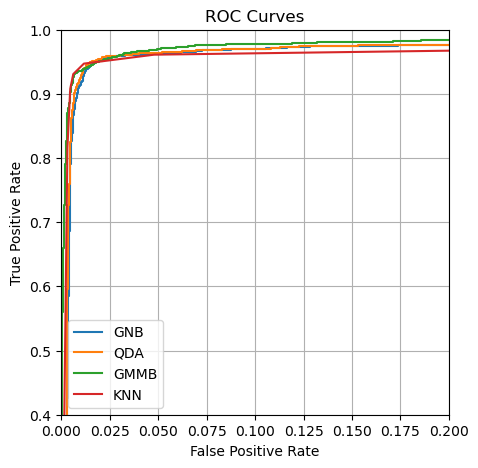

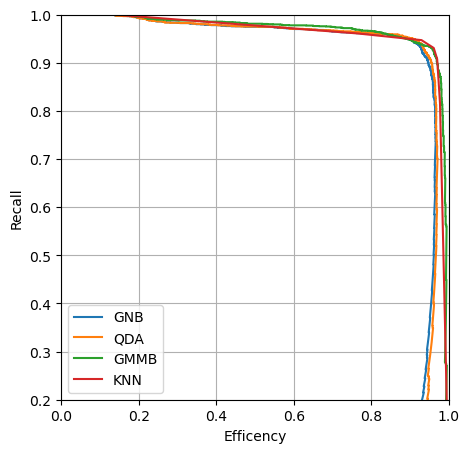

In [18]:
plt.figure(figsize=(5, 5))
for i in range(len(models)):
    plt.plot(fpr[i], tpr[i], label=names[i])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.xlim(0,0.2)
plt.ylim(0.4,1)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 5))
for i in range(len(models)):
    plt.plot(pre[i], rec[i], label=names[i])
plt.xlabel('Efficency')
plt.ylabel('Recall')
plt.xlim(0,1)
plt.ylim(0.2,1.)
plt.legend()
plt.grid(True)
plt.show()

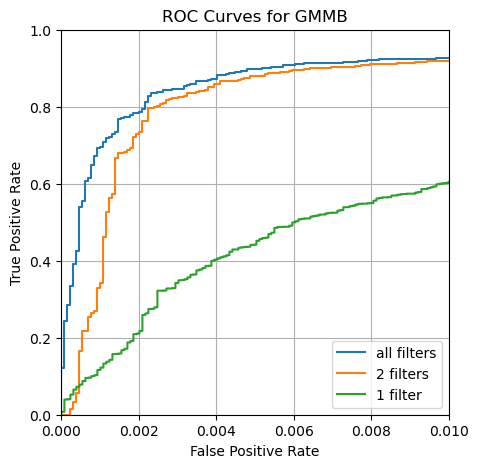

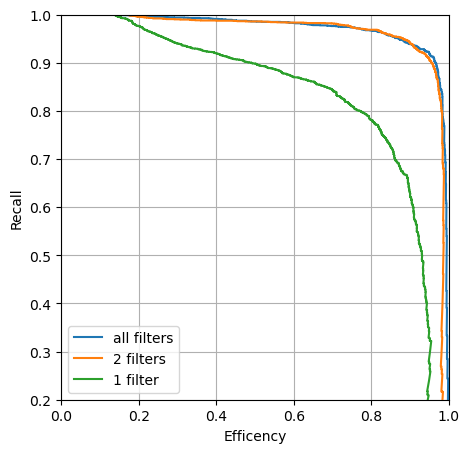

In [19]:
#Let's compare the results we get by using different number of filters:
plt.figure(figsize=(5, 5))
plt.plot(fpr_tot[2], tpr_tot[2], label='all filters')
plt.plot(fpr_cls[2], tpr_cls[2], label='2 filters')
plt.plot(fpr_one[2], tpr_one[2], label='1 filter')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for GMMB')
plt.xlim(0,0.01)
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 5))
plt.plot(pre_tot[2], rec_tot[2], label='all filters')
plt.plot(pre_cls[2], rec_cls[2], label='2 filters')
plt.plot(pre_one[2], rec_one[2], label='1 filter')
plt.xlabel('Efficency')
plt.ylabel('Recall')
plt.xlim(0,1)
plt.ylim(0.2,1)
plt.legend()
plt.grid(True)
plt.show()

Using all of the data available seems to be best thing we can do! Now, to do even better, let's tune the hyperparameters with some CV:

In [20]:
from sklearn.model_selection import GridSearchCV

X = np.column_stack([ug_train, gr_train, ri_train, iz_train])
X_test = np.column_stack([ug_test, gr_test, ri_test, iz_test])
y = class_train

n_components_range = [np.array([i]) for i in range(1, 8)]
N_comp = {'n_components': n_components_range}

grid = GridSearchCV(GMMBayes(), N_comp, cv=5, scoring='accuracy')

grid.fit(X, y)

print("Best n_components:", grid.best_params_['n_components'][0])
print("Best accuracy:", grid.best_score_)

bst_model = grid.best_estimator_


Best n_components: 7
Best accuracy: 0.9824285714285714


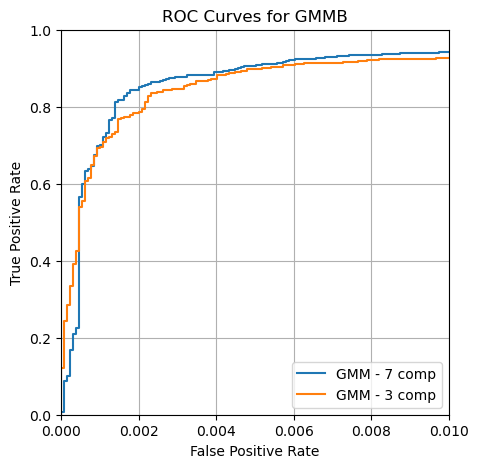

In [22]:
y_best = bst_model.predict_proba(X_test)
fpr_bst, tpr_bst, th_bst = ROC(class_test, y_best[:, 1])
pr_bst, acc_bst, th_bst = PRC(class_test, y_pred[:, 1])

plt.figure(figsize=(5, 5))
plt.plot(fpr_bst, tpr_bst, label='GMM - 7 comp')
plt.plot(fpr_tot[2], tpr_tot[2], label='GMM - 3 comp')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for GMMB')
plt.xlim(0,0.01)
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()


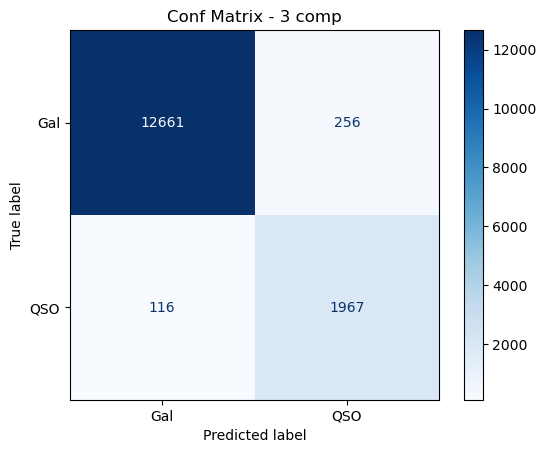

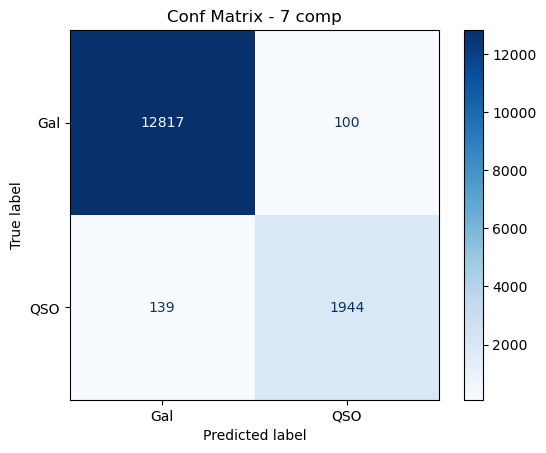

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

GMMB.fit(X, y)
y_pred_3 = GMMB.predict(X_test)

y_pred_bst = bst_model.predict(X_test)

cm_3 = confusion_matrix(class_test, y_pred_3)
cm_bst = confusion_matrix(class_test, y_pred_bst)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_3, display_labels=['Gal', 'QSO'])
disp.plot(cmap='Blues')
plt.title("Conf Matrix - 3 comp")
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=cm_bst, display_labels=['Gal', 'QSO'])
disp.plot(cmap='Blues')
plt.title("Conf Matrix - 7 comp")
plt.show()

We perform much batter on the Galaxy side, while the QSO identification stays pratically the same! Good!